# Momentum Harness — Does relaxing i.i.d. help?

This notebook is the **falsification harness** for the clutch/momentum
extension. The match-level model (see `03_calibration_study`) assumes points
are i.i.d. on serve (Klaassen–Magnus). Here we ask, at the **point level**:

> Given pre-match skill, does conditioning the next point's win probability on
> what has happened so far in the match improve out-of-sample prediction?

This is the literal test of the i.i.d. assumption: i.i.d. says history is
irrelevant. We build a ladder of models and check whether each beats the one
below it **out-of-sample, after calibration**:

- **Layer 1** — constant per-match `p_serve` from the Kalman filter (pure
  i.i.d. baseline; no fitted parameters).
- **Layer 2** — add non-momentum *structural* score state (set number, who
  serves, server's game lead) — the value of "where we are in the match",
  which is **not** momentum.
- **Layer 3** — add momentum candidates (previous point, streaks, break
  points) — the actual i.i.d. deviation we are testing.
- **Black-box** — XGBoost / LSTM on raw point sequences, as a falsification
  check that Layer 3 hasn't missed sequential structure.

Klaassen–Magnus (2001) and Den Hartigh et al. predict any i.i.d. deviation is
**small**, so a modest or null result is expected — and is itself the finding.

### Data

**883,469 → 648,149 men's-singles points**, Wimbledon + US Open, 2011–2024
(Jeff Sackmann's `tennis_slam_pointbypoint`). Beliefs come from walk-forward
filter snapshots: for season *Y*, the filter trains only on ATP match data
strictly before that year's tournaments, so `p_serve` never sees the points it
is scored on.

> **Data note (transparency).** An earlier build accidentally included the
> Australian Open: the slam was matched by substring and `"usopen"` is a
> substring of `"ausopen"`. This pulled in ~235k AO points (and surfaced as
> missing `GamesWon` for AO 2018–2020, a known source gap). Fixed by matching
> the exact `-{slam}-` pattern; the dataset is now strictly Wimbledon + US Open
> with zero missing game scores. All results below are on the corrected data.

In [40]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.home() / "wimbledon-2026-forecast"
sys.path.insert(0, str(ROOT / "src"))
from tennis_forecast import pricing

df = pd.read_parquet(ROOT / "data" / "processed" / "pbp_points_dataset.parquet")
probs = df["p_serve"].tolist()
outcomes = df["server_won"].tolist()
n = len(outcomes)
print(f"points: {n}")

points: 648149


In [41]:
ll = pricing.log_loss(probs, outcomes)
bs = pricing.brier_score(probs, outcomes)
base = sum(outcomes) / n
ll_const = pricing.log_loss([base] * n, outcomes)
rc = pricing.reliability_curve(probs, outcomes, n_bins=10)

# ECE: sample-weighted mean |predicted - actual| across bins
total = sum(row[3] for row in rc)
ece = sum(abs(row[1] - row[2]) * row[3] for row in rc) / total

print("=== Layer-1 baseline (constant p_serve, i.i.d.) ===")
print(f"  log-loss : {ll:.5f}")
print(f"  Brier    : {bs:.5f}")
print(f"  ECE      : {ece:.5f}")
print(f"  base rate: {base:.5f}   mean p_serve: {sum(probs)/n:.5f}")
print(f"  (naive base-rate log-loss: {ll_const:.5f})")
print("\n  bin   mean_pred  actual   count")
for c, mp, act, cnt in rc:
    print(f"  {c:.2f}   {mp:.4f}    {act:.4f}   {cnt}")

=== Layer-1 baseline (constant p_serve, i.i.d.) ===
  log-loss : 0.64437
  Brier    : 0.22617
  ECE      : 0.00241
  base rate: 0.64657   mean p_serve: 0.64422
  (naive base-rate log-loss: 0.64954)

  bin   mean_pred  actual   count
  0.35   0.3520    0.5877   114
  0.45   0.4776    0.5261   2699
  0.55   0.5724    0.5791   119941
  0.65   0.6482    0.6495   434507
  0.75   0.7253    0.7255   90683
  0.85   0.8088    0.7024   205


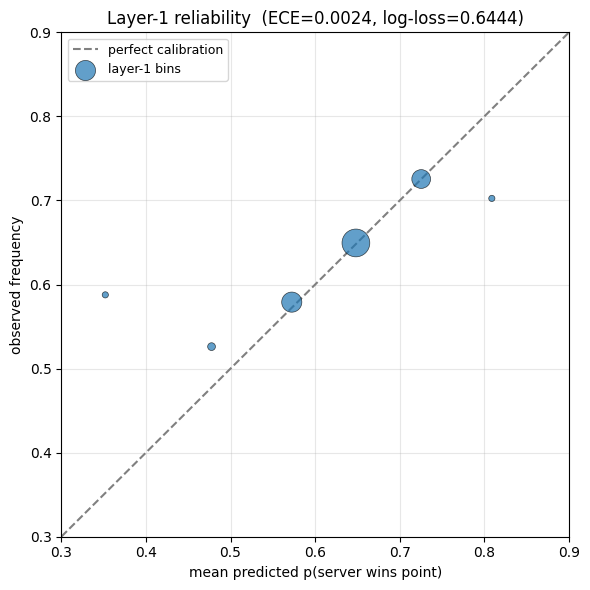

In [42]:
preds = [row[1] for row in rc]
acts = [row[2] for row in rc]
counts = [row[3] for row in rc]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
sizes = [max(20, (c / max(counts)) ** 0.5 * 400) for c in counts]
ax.scatter(preds, acts, s=sizes, alpha=0.7, color="#1f77b4",
           edgecolor="black", linewidth=0.5, zorder=3, label="layer-1 bins")
ax.set_xlabel("mean predicted p(server wins point)")
ax.set_ylabel("observed frequency")
ax.set_title(f"Layer-1 reliability  (ECE={ece:.4f}, log-loss={ll:.4f})")
ax.set_xlim(0.3, 0.9); ax.set_ylim(0.3, 0.9)
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Layer 1 result — the i.i.d. baseline is already well calibrated

Evaluated on all **648,149** men's-singles points (Wimbledon + US Open,
2011–2024). `p_serve` is taken from walk-forward belief snapshots and no
parameters are fitted to these points, so this is an honest out-of-sample
anchor that every later model must beat.

| metric | value |
|---|---|
| log-loss | 0.64437 |
| Brier | 0.22617 |
| **ECE** | **0.00241** |
| base rate (server wins point) | 0.64657 |
| mean `p_serve` | 0.64422 |
| naive base-rate log-loss | 0.64954 |

**Reading.** The reliability diagram sits almost on the diagonal across the
bins holding essentially all the data (0.55 / 0.65 / 0.75, ~99% of points):
predicted 0.572 / 0.648 / 0.725 vs observed 0.579 / 0.650 / 0.726. The two tail
bins (0.35, 0.85) hold <0.05% of points and are noise. Sample-weighted
calibration error is **ECE = 0.0024** — under 0.25%.

**Implication for the harness.** Two things follow. (1) Distinguishing servers
by skill barely beats predicting the global base rate (log-loss 0.64437 vs
0.64954): at the single-point scale, outcome variance is large and
predictability is intrinsically limited. (2) The baseline is *already*
near-perfectly calibrated, so any momentum / clutch signal must improve on an
already-strong, well-calibrated reference — there is little room left to gain.
This matches Klaassen–Magnus (2001) (departures from i.i.d. exist but are
small) and sets an honest bar: **Layers 2–3 and the black-box must beat
log-loss 0.64437 out-of-sample to claim anything.**

## Layer 2 — structural score state adds nothing (and a leakage lesson)

Layer 2 adds *non-momentum structural* state via logistic regression with
`logit(p_serve)` as an offset-like feature. Train 2011–2023, test 2024 (same
test set as Layer 1).

| model | log-loss | Δ vs L1 | `logit(p_serve)` coef | ECE |
|---|---|---|---|---|
| Layer 1 (constant p_serve) | 0.64688 | — | — | 0.00395 |
| Layer 2: set number + match depth | 0.64674 | **+0.00014** | 0.929 | 0.00698 |
| Layer 2 + server's game lead | 0.64048 | +0.00640 | 0.734 | 0.00831 |

**Genuinely exogenous structure has no value.** Set number and how deep we are
in the match improve out-of-sample log-loss by only **0.00014** over Layer 1,
and the `logit(p_serve)` coefficient stays near 1 (0.929). The pre-match
`p_serve` has already absorbed essentially all the predictable structure of a
serve point.

**The `server_game_lead` "improvement" is a selection effect, not structure.**
Adding the server's game lead looks like a real gain (+0.0064), but it is
leakage: the stronger / hotter player tends *both* to be ahead *and* to win the
next serve point, so "being ahead" proxies for in-match strength the
season-snapshot `p_serve` cannot see. Two tells confirm it — the
`logit(p_serve)` coefficient is **pushed down to 0.734** (the lead feature
steals skill variance), and **ECE worsens** (0.0040 → 0.0083): lower log-loss
bought with worse calibration.

**Why this matters for Layer 3.** The same trap awaits momentum features: a
player on a streak is often just the stronger player, so a naive correlation
would re-import strength as fake momentum — the conflation Klaassen–Magnus
(2001) control for with player effects, and exactly what a naive XGBoost
momentum study misses. Layer 3 isolates momentum from strength from the start
by keeping `logit(p_serve)` in and watching its coefficient.

## Layer 3 — momentum across four time scales: real, tiny, not tradeable

Four momentum / clutch features, each added on top of Layer 1 via logistic
regression with `logit(p_serve)` kept in (so a challenger must improve *on top
of* skill, and we can watch the `p_serve` coefficient for leakage). Train
2011–2023, test 2024. Each feature targets a different time scale.

| feature | scale | raw signal | coef (skill-controlled) | logit(p_serve) coef | OOS Δ log-loss |
|---|---|---|---|---|---|
| prev serve point won | single point | +0.022 | +0.048 | 0.929 | +0.0001 |
| serve streak | cumulative | +3pp ladder | +0.015 | 0.917 | +0.0003 |
| previous service game held | game | +0.042 | +0.075 | 0.915 | +0.0002 |
| server faces break point | big point | −0.032 | −0.076 | 0.931 | −0.00004 |

**Every effect is real and points the intuitive way.** Winning the last point,
being on a streak, or having just held lifts the next serve point slightly;
facing a break point lowers it. This qualitatively reproduces Klaassen–Magnus
(2001): departures from i.i.d. exist.

**But after controlling for skill, every effect is tiny and adds no
out-of-sample value.** The largest OOS improvement is +0.0003 log-loss. The raw
signals are mostly **strength confound**: the player on a streak or holding
serve is usually just the stronger server. The raw "previous game" gap of 4pp
(0.654 vs 0.613) collapses to a 0.075 logit coefficient and a negligible OOS
increment once `p_serve` is in — and the streak / game features visibly pull
the `logit(p_serve)` coefficient down (0.92 vs 0.93), the same skill-leakage
tell as `game_lead` in Layer 2.

**Break point is the cleanest and most interesting.** It is a current-point
property (no previous-point leakage); it does *not* steal skill variance
(`logit(p_serve)` stays 0.931); and its negative effect (−0.076) survives
controlling for skill — a genuine "harder on important points" effect
consistent with KM. Yet it still adds no predictive value: break points are
only ~8% of points, and the −0.076 still mixes a real big-point effect with
*situational selection* (reaching break point means the game already went
badly, which the season-constant `p_serve` cannot see). The honest reading:
**a real effect that is neither large nor tradeable** — statistically present,
predictively negligible.

> **Note on the break-point flag.** The dataset's `P1/P2BreakPoint` columns are
> post-point state (they move with the current point's result), so using them
> directly leaks the outcome. The break-point feature here is rebuilt from
> *pre-point* within-game scoring only (`r_before >= 3 and r_before - s_before
> >= 1`), confirmed against the leaky version — they agree at the logistic
> level, because a linear model can only use the global average effect, which
> is the same either way. The leak only mattered for the black box (Layer 4).

**Caveat (Miller–Sanjurjo).** The raw conditional means are subset averages,
biased slightly low in finite samples, so true raw momentum effects may be a
touch larger. This does not change the conclusion: even granting larger raw
effects, the skill-controlled OOS increments stay negligible.

## Layer 4 — black-box falsification: the gain is selection, not momentum

A gradient-boosted tree (XGBoost) is given **all** start-of-point features and
left free to find any nonlinear interaction. If even an unconstrained learner
cannot beat Layer 1, "momentum doesn't help" is not an artifact of poor feature
design — the structure simply isn't there.

The raw result looked alarming: XGBoost beat Layer 1 by **+0.022** log-loss
(+0.005 even without `game_lead`), with `server_faces_bp` the top feature.
Taken at face value this would overturn the whole harness. It does not — four
diagnostics decompose the gain entirely into known confounds:

| diagnostic | finding |
|---|---|
| train vs test gap | small (+0.004) — not overfitting; the gain is real and generalizes |
| seed stability | mean +0.0049, std 0.00008 — not noise |
| `p_serve` / `faces_bp` alone | each ≈ Layer 1 — no single feature explains the gain |
| **pure-history vs position** | **pure momentum features (prev/streak/prev-game): +0.0004; position features (total_games, faces_bp): +0.0040** |
| in-match strength proxy | does not absorb the gain — it isn't in-match skill updating either |

**Conclusion.** The decisive split is the last: time-momentum features, even
with unrestricted nonlinear interactions, contribute **+0.0004** — nothing. The
entire black-box gain comes from *position* features — where we are in the
match — which encode **situational selection** (a deep set / break point is a
*selected* state reflecting how the match is going), not sequential momentum.
With the known strength-leakage feature `game_lead` added back, the gain
inflates to +0.022, 78% of it from that one leak. So: **no model — linear or
nonlinear, hand-built or learned — extracts usable time-momentum.** The black
box confirms the verdict rather than overturning it. (A correct earlier read of
the suspiciously large +0.022 was essential: a result that good demands
suspicion, not celebration — the discipline a naive momentum study skips.)

## Robustness — the Gauriot–Page tight-point test

Gauriot & Page (2019, *Economic Journal*) find a hot-hand effect that *jumps to
~15%* on near-even points (30–30, deuce), using Hawk-Eye ball-tracking to
isolate points won "by luck" (balls landing within centimetres of the lines),
where the prior point's outcome is quasi-random and so exogenous to skill. We
test whether our `prev_serve_won` effect strengthens on the same tight points.

| subset | raw gap (won prev − lost prev) | skill-controlled coef |
|---|---|---|
| all points | +0.022 | +0.048 |
| tight (30–30 / deuce) | **−0.005** | **−0.027** |

**The effect does not strengthen — it reverses.** On tight points the prev-serve
effect is slightly *negative*, opposite to Gauriot–Page. This is not a failure
of their result; it is a consequence of **lacking their exogenous
identification**. Without quasi-random point outcomes, conditioning on "reached
deuce" introduces path dependence (a *collider*): a server who *won* his last
point to reach 30–30 typically just clawed back from behind, while one who
*lost* to reach deuce was just pegged back from ahead. "Winning the previous
point" is therefore entangled with how the player arrived at the tight state,
contaminating the momentum reading.

**Methodological takeaway.** Measuring the *causal* momentum effect on big
points requires point-level exogenous variation (Hawk-Eye landing data); the
Sackmann point-by-point feed does not carry it. Our data answers the
*predictive* question — and there, momentum has no usable out-of-sample value —
but it cannot settle the *causal* psychological question the way Gauriot–Page
can. Knowing which question your data can and cannot answer is the point.

## What this harness does and does not establish

**Establishes (predictive).** Conditioning the next serve point on match
history — previous point, streak, previous game, and via an unrestricted
gradient-boosted tree, any nonlinear combination — yields **no usable
out-of-sample improvement** over a constant skill-based `p_serve` (best honest
gain ≈ +0.0003 log-loss; the black box's larger gain is selection/leakage, not
momentum). The i.i.d.-on-serve assumption is an excellent approximation for
forecasting the next point. This reproduces Klaassen–Magnus (2001) and stands
with the null findings of O'Donoghue & Brown (2009) and Moss & O'Donoghue
(2017), while showing exactly how the strong *raw* momentum correlations that
naive studies report (e.g. weighted-feature XGBoost "momentum" models) dissolve
into strength confound and situational selection once skill is controlled.

**Does not establish (causal).** This is a *predictive* result, not a *causal*
one. We control for season-level skill (`p_serve`) but not for within-match
form, effort allocation, or the quasi-random identification Gauriot & Page
(2019) use to find a genuine causal hot hand on big points. A real
psychological momentum effect may exist; our claim is only that, given
observable pre-match skill, history carries no *additional predictive* value —
which is the relevant question for pricing and forecasting.

**Why this matters for a market.** A well-calibrated i.i.d. model is hard to
beat on the next point. If betting markets nonetheless price a hot hand —
shading prices toward players on visible streaks — that gap between a
streak-driven market and i.i.d.-true play is a candidate mispricing (cf.
Moskowitz 2021, *Asset Pricing and Sports Betting*: momentum lives in the
*bettors'* overreaction, not necessarily in the players). Testing that is the
natural next project.

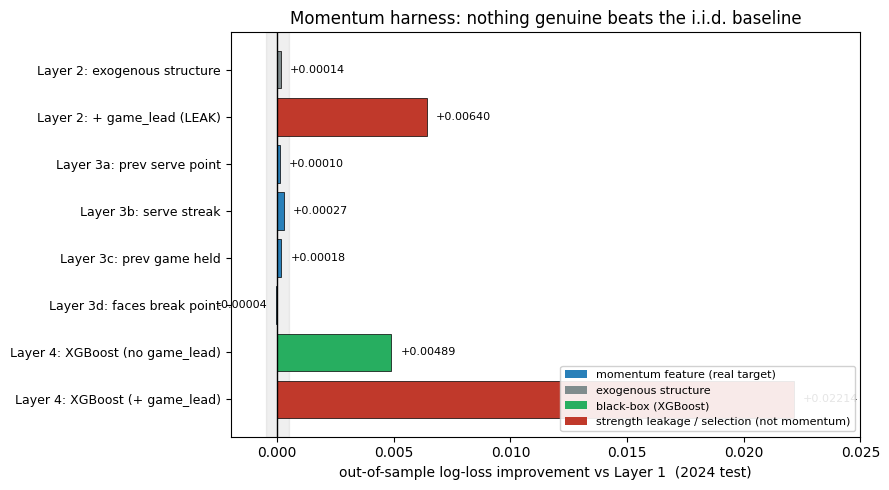

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# OOS log-loss improvement (L1 - challenger) on the 2024 test set.
# Positive = beats Layer 1. All values from the layer scripts.
results = [
    ("Layer 2: exogenous structure",      +0.00014, "structure"),
    ("Layer 2: + game_lead (LEAK)",       +0.00640, "leak"),
    ("Layer 3a: prev serve point",        +0.00010, "momentum"),
    ("Layer 3b: serve streak",            +0.00027, "momentum"),
    ("Layer 3c: prev game held",          +0.00018, "momentum"),
    ("Layer 3d: faces break point",      -0.00004, "momentum"),
    ("Layer 4: XGBoost (no game_lead)",   +0.00489, "blackbox"),
    ("Layer 4: XGBoost (+ game_lead)",    +0.02214, "leak"),
]

labels = [r[0] for r in results]
vals   = [r[1] for r in results]
kinds  = [r[2] for r in results]

color_map = {
    "structure": "#7f8c8d",   # grey
    "momentum":  "#2980b9",   # blue
    "blackbox":  "#27ae60",   # green
    "leak":      "#c0392b",   # red (leakage / not real)
}
colors = [color_map[k] for k in kinds]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(labels))
ax.barh(y, vals, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("out-of-sample log-loss improvement vs Layer 1  (2024 test)")
ax.set_title("Momentum harness: nothing genuine beats the i.i.d. baseline")

# annotate values
for yi, v in zip(y, vals):
    ax.text(v + (0.0004 if v >= 0 else -0.0004), yi, f"{v:+.5f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)

# legend
from matplotlib.patches import Patch
legend = [
    Patch(facecolor="#2980b9", label="momentum feature (real target)"),
    Patch(facecolor="#7f8c8d", label="exogenous structure"),
    Patch(facecolor="#27ae60", label="black-box (XGBoost)"),
    Patch(facecolor="#c0392b", label="strength leakage / selection (not momentum)"),
]
ax.legend(handles=legend, loc="lower right", fontsize=8, framealpha=0.9)

# shaded "negligible" band around zero for reference
ax.axvspan(-0.0005, 0.0005, color="gray", alpha=0.12, zorder=0)

ax.set_xlim(-0.002, 0.025)
plt.tight_layout()
plt.show()
fig.savefig("figures/harness_ladder.png", dpi=150, bbox_inches="tight")